In [1]:
"""
Compute a monthly climatology from a BATS primary productivity dataset.

This script downloads (or reads locally) a CSV file containing
14C primary productivity data collected at the Bermuda Atlantic
Time‑series Study (BATS).  It processes the data into a seasonal
climatology on a fixed depth grid and returns an ``xarray.Dataset``
with dimensions ``month`` and ``depth``.  The main variable of
interest is primary production (NPP), which is computed either from
the pre‑calculated ``pp`` column (mean of light bottles minus dark
bottle) if available, or derived from the replicate light and dark
bottles (``lt1``, ``lt2``, ``lt3``, and ``dark``) when ``pp`` is
missing.  All values are expressed in mg C m⁻³ day⁻¹.

depths are snapped to a standard grid, dates are parsed and binned by
month, and mean values across all years are computed for each month
and depth.

Requirements:

* pandas
* numpy
* xarray
* requests (only if downloading from HTTP)

"""

from __future__ import annotations

import io
import warnings
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import xarray as xr
import requests

__all__ = [
    'STANDARD_DEPTHS',
    'DEPTH_TOLERANCE',
    'download_npp_data',
    'preprocess_npp',
    'compute_monthly_climatology',
    'build_npp_climatology',
]

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [2]:

# Define a standard depth grid (in metres) appropriate for the BATS pigment
# dataset.  BATS pigment casts usually sample 12 depths between 0 and
# roughly 250 m.  Here we adopt a 10 m resolution up to 300 m, which is
# flexible enough to accommodate occasional deeper samples.  Adjust this
# array if you wish to alter the vertical resolution or range.
STANDARD_DEPTHS: np.ndarray = np.arange(0, 301, 20)

# Maximum difference (in metres) allowed when matching observed depths to
# ``STANDARD_DEPTHS``.  If the absolute difference between an observed
# depth and the nearest standard depth exceeds this value, the sample is
# discarded.  Increase this tolerance to retain more data, or decrease it
# to enforce stricter matching.
DEPTH_TOLERANCE: float = 10.0


### DOWNLOAD

In [6]:
def download_npp_data(url_or_path: str) -> pd.DataFrame:
    """Download or read the primary productivity dataset into a DataFrame.

    Parameters
    ----------
    url_or_path : str
        Either an HTTP(S) URL pointing to a CSV file or a local file path.

    Returns
    -------
    pandas.DataFrame
        The raw dataset.  Returns an empty DataFrame if the file
        cannot be read or downloaded.
    """
    try:
        if url_or_path.startswith(('http://', 'https://')):
            resp = requests.get(url_or_path, timeout=60)
            resp.raise_for_status()
            content = resp.content
            return pd.read_csv(io.BytesIO(content), dtype=str)
        else:
            return pd.read_csv(url_or_path, dtype=str)
    except Exception as exc:
        warnings.warn(f"Failed to load NPP data from {url_or_path}: {exc}")
        return pd.DataFrame()


### PROCESS

In [7]:
def preprocess_npp(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess the raw NPP DataFrame.

    The function performs the following operations:

    * Parse the primary date column.  The NPP dataset contains
      multiple date/time fields; if ``ISO_DateTime_UTC_CTD_in``
      exists it is used, otherwise ``ISO_DateTime_UTC_Array_in`` or
      ``Date`` is used as a fallback.
    * Extract month indices (1–12).
    * Convert ``Depth`` values to floats and snap them to the
      ``STANDARD_DEPTHS`` grid within ``DEPTH_TOLERANCE``.
    * Compute the primary production value ``npp`` for each sample.
      If the column ``pp`` exists it is used directly; otherwise
      ``npp`` is calculated as the mean of ``lt1``, ``lt2``, ``lt3``
      minus the ``dark`` bottle.
    * Convert ``npp`` to numeric and drop rows without valid values.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw primary productivity data.

    Returns
    -------
    pandas.DataFrame
        A tidy DataFrame with columns ``month``, ``depth`` and ``npp``.
    """
    if df.empty:
        return df

    # Determine which date column to use
    date_columns = [
        'ISO_DateTime_UTC_CTD_in',
        'ISO_DateTime_UTC_Array_in',
        'ISO_DateTime_UTC',  # generic fallback
        'Date'
    ]
    date_col = None
    for col in date_columns:
        if col in df.columns:
            date_col = col
            break
    if date_col is None:
        warnings.warn("No valid date column found in NPP data.")
        return pd.DataFrame()
    df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month

    # Depth handling
    if 'Depth' not in df.columns:
        warnings.warn("No 'Depth' column found in NPP data.")
        return pd.DataFrame()
    df['depth_orig'] = pd.to_numeric(df['Depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)
    # Snap to standard grid
    idxs = np.abs(df['depth_orig'].values[:, None] - STANDARD_DEPTHS[None, :]).argmin(axis=1)
    snapped_depths = STANDARD_DEPTHS[idxs]
    within = np.abs(df['depth_orig'] - snapped_depths) <= DEPTH_TOLERANCE
    df = df.loc[within].copy()
    df['depth'] = snapped_depths[within.values]

    # Compute NPP values
    npp_values = None
    if 'pp' in df.columns:
        npp_values = pd.to_numeric(df['pp'], errors='coerce')
    else:
        # Attempt to compute from replicate light bottles and dark bottle
        # Convert replicate columns to numeric; missing columns yield NaN
        lt_cols = []
        for col in ('lt1', 'lt2', 'lt3'):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                lt_cols.append(col)
        if lt_cols:
            light_mean = df[lt_cols].mean(axis=1)
        else:
            light_mean = pd.Series(np.nan, index=df.index)
        dark = pd.to_numeric(df['dark'], errors='coerce') if 'dark' in df.columns else pd.Series(np.nan, index=df.index)
        npp_values = light_mean - dark
    df['npp'] = npp_values
    # Drop rows without valid NPP values
    df.dropna(subset=['npp'], inplace=True)

    # Construct tidy DataFrame
    return df[['month', 'depth', 'npp']]


### CLIMATOLOGY

In [8]:
def compute_monthly_climatology(df: pd.DataFrame) -> xr.Dataset:
    """Aggregate NPP data into a monthly climatology.

    Parameters
    ----------
    df : pandas.DataFrame
        Tidy DataFrame with columns ``month``, ``depth`` and ``npp``.

    Returns
    -------
    xarray.Dataset
        Dataset with dimensions ``month`` and ``depth`` containing the
        mean NPP (mg C m⁻³ day⁻¹) for each month and depth across all years.
    """
    months = np.arange(1, 13)
    depths = STANDARD_DEPTHS.copy()
    # Pivot table to compute means
    pivot = df.pivot_table(index='month', columns='depth', values='npp', aggfunc='mean')
    pivot = pivot.reindex(index=months, columns=depths)
    ds = xr.Dataset(
        data_vars={'npp': (('month', 'depth'), pivot.values.astype(float))},
        coords={'month': months, 'depth': depths},
        attrs={'description': 'Monthly climatology of BATS primary production on a fixed depth grid',
               'units': 'mg C m^-3 day^-1'}
    )
    return ds


### BUILD

In [9]:
def build_npp_climatology(url_or_path: str, depth_grid: Optional[np.ndarray] = None) -> xr.Dataset:
    """Download, preprocess and compute a monthly climatology for primary production.

    Parameters
    ----------
    url_or_path : str
        HTTP(S) URL to the CSV file or a local file path.  If the file is
        already available locally, providing the path avoids network
        latency.
    depth_grid : array-like of float, optional
        Override the default ``STANDARD_DEPTHS``.  If supplied, this
        array will replace the global grid used to snap depths and define
        the climatology depth axis.  You may also adjust the global
        ``DEPTH_TOLERANCE`` to suit the new grid.

    Returns
    -------
    xarray.Dataset
        Monthly climatology dataset with a single variable ``npp``.
    """
    global STANDARD_DEPTHS
    if depth_grid is not None:
        STANDARD_DEPTHS = np.asarray(depth_grid, dtype=float)
    raw = download_npp_data(url_or_path)
    tidy = preprocess_npp(raw)
    if tidy.empty:
        raise RuntimeError("No valid primary production data after preprocessing.")
    return compute_monthly_climatology(tidy)


### call

In [10]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/893182/file/wn3ZkYAhjxRvA/893182_v7_bats_primary_production.csv"
ds = build_npp_climatology(link)
print(ds)


<xarray.Dataset> Size: 2kB
Dimensions:  (month: 12, depth: 16)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth    (depth) int64 128B 0 20 40 60 80 100 ... 200 220 240 260 280 300
Data variables:
    npp      (month, depth) float64 2kB 8.746 7.903 5.432 2.522 ... nan nan nan
Attributes:
    description:  Monthly climatology of BATS primary production on a fixed d...
    units:        mg C m^-3 day^-1
CPU times: user 662 ms, sys: 330 ms, total: 993 ms
Wall time: 4.77 s


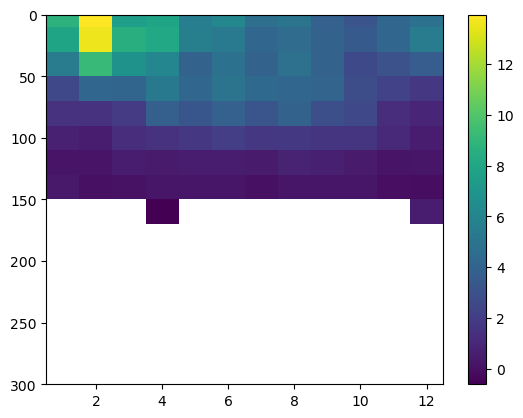

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['npp'].T)
plt.ylim(300,0)
plt.colorbar()


### SAVE

In [12]:
%%time
    
ds.to_netcdf('./bats_npp_monthly_climatology.nc')

CPU times: user 266 ms, sys: 94.5 ms, total: 361 ms
Wall time: 1.12 s
